In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 

In [3]:
df = pd.read_csv('/Users/meetsudra/Documents/GitHub/real-estate/above csvs/gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.shape

(3678, 19)

In [5]:
df.head()

,Unnamed: 0,property_type,sector,society,price,price_per_sqft,built_up_area,bedRoom,bathroom,balcony,floorNum,agePossession,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,sector 86,ansal heights 86,0.78,5735.29,1360.0,2,2,2,8.0,New Property,0,0,0,0,0,1,72
1,1,flat,sector 103,indiabulls centrum park,1.05,5859.38,1365.0,2,2,3,1.0,Relatively New,0,0,0,0,0,2,51
2,2,flat,sector 70a,bptp astaire gardens,0.97,6585.20,1339.0,3,3,3+,1.0,Relatively New,0,0,0,0,1,1,149
3,3,flat,sector 69,tulip violet,2.05,9951.46,1889.0,4,4,2,0.0,Relatively New,0,0,0,0,0,1,157
4,5,flat,sector 92,bestech park view sanskruti,1.83,7870.97,2104.0,4,3,3,8.0,New Property,0,1,0,0,0,1,128


In [6]:
latlong = pd.read_csv('/Users/meetsudra/Documents/GitHub/real-estate/latlong.csv')


In [7]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [8]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [9]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [10]:
new_df = df.merge(latlong, on='sector')

In [11]:
new_df.head()

,Unnamed: 0,property_type,sector,society,price,price_per_sqft,built_up_area,bedRoom,bathroom,balcony,...,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,coordinates,latitude,longitude
0,0,flat,sector 86,ansal heights 86,0.78,5735.29,1360.0,2,2,2,...,0,0,0,0,0,1,72,"28.3986° N, 76.9384° E",28.3986,76.9384
1,1,flat,sector 103,indiabulls centrum park,1.05,5859.38,1365.0,2,2,3,...,0,0,0,0,0,2,51,"28.4949° N, 76.9845° E",28.4949,76.9845
2,3,flat,sector 69,tulip violet,2.05,9951.46,1889.0,4,4,2,...,0,0,0,0,0,1,157,"28.3966° N, 77.0341° E",28.3966,77.0341
3,5,flat,sector 92,bestech park view sanskruti,1.83,7870.97,2104.0,4,3,3,...,0,1,0,0,0,1,128,"28.4079° N, 76.9153° E",28.4079,76.9153
4,6,flat,sector 56,the castle society,2.00,8695.65,2081.0,4,4,2,...,0,0,0,0,0,1,0,"28.4245° N, 77.0991° E",28.4245,77.0991


In [12]:
new_df.dtypes

Unnamed: 0           int64
property_type       object
sector              object
society             object
price              float64
price_per_sqft     float64
built_up_area      float64
bedRoom              int64
bathroom             int64
balcony             object
floorNum           float64
agePossession       object
study room           int64
servant room         int64
store room           int64
pooja room           int64
others               int64
furnishing_type      int64
luxury_score         int64
coordinates         object
latitude           float64
longitude          float64
dtype: object

In [13]:
numeric_cols = ['price', 'price_per_sqft', 'built_up_area', 'latitude', 'longitude']
group_df = new_df.groupby('sector')[numeric_cols].mean()
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.794444,3056.166667,28.4484,77.0210
manesar,0.962258,4608.077097,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.791667,2327.833333,28.3663,76.9456
sector 102,1.681327,10641.026460,1545.486726,28.4750,76.9715
sector 103,1.441556,7424.559333,1804.533333,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.921154,5891.280673,1560.069038,28.4079,76.9153
sector 93,0.808182,8516.398182,941.272727,28.4153,76.9326
sector 95,0.486610,5595.269322,1011.694915,28.4172,76.9081


In [14]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

- from sector 1 to 10 we can see the prices are comaparatively less then the right side part where prices are high. These sectors belong to old gurgaon

- top area have comparatively high prices then those in bottom left since they belong to region where delhi is near 

In [15]:
new_df.to_csv('data_viz1.csv',index=False)

# Word Cloud Ammenities

In [16]:
df1 = pd.read_csv('/Users/meetsudra/Documents/GitHub/real-estate/gurgaon.csv')
df1.head()

,Unnamed: 0,property_name,property_type,society,price,area,price_per_sqft,areaWithType,bedRoom,bathroom,...,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,0,2 BHK Flat in Sector 86 Gurgaon,flat,ansal heights 86,0.78,1360.0,5735.0,Built Up area: 1360 (126.35 sq.m.),2,2,...,not available,"Tower I, Sector 86 Gurgaon, Gurgaon, Haryana",8.0,North,0 to 1 Year Old,"['IRIS Broadway Mall', 'Delhi Jaipur Expresswa...",Park facing north facing unit - 8th floor. Pos...,NaN,"['Feng Shui / Vaastu Compliant', 'Security / F...","['Safety4.5 out of 5', 'Lifestyle5 out of 5', ..."
1,1,2 BHK Flat in Sector 103 Gurgaon,flat,indiabulls centrum park,1.05,1792.0,5861.0,Built Up area: 1365 (126.81 sq.m.)Carpet area:...,2,2,...,not available,"C Block, Sector 103 Gurgaon, Gurgaon, Haryana",1.0,West,1 to 5 Year Old,"['Gurgaon Dreamz Mall', 'HUDA Market, Sector 1...",2bhk multistorey apartment for resale in india...,"['2 Wardrobe', '4 Fan', '2 Geyser', '15 Light'...",NaN,"['Management4 out of 5', 'Green Area5 out of 5..."
2,2,3 BHK Flat in Sector 70A Gurgaon,flat,bptp astaire gardens,0.97,1473.0,6587.0,Super Built up area 1480(137.5 sq.m.),3,3,...,others,"Sector 70a, Sector 70A Gurgaon, Gurgaon, Haryana",1.0,West,1 to 5 Year Old,"['Sector 54 Chowk Metro Station', 'Airia Mall'...",An east facing 3 bhk resale flat is available ...,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Green Area4 out of 5', 'Construction5 out of..."
3,3,4 BHK Flat in Sector 69 Gurgaon,flat,tulip violet,2.05,2060.0,9950.0,Super Built up area 2087(193.89 sq.m.),4,4,...,not available,"003, Sector 69 Gurgaon, Gurgaon, Haryana",0.0,North-West,1 to 5 Year Old,"['Airia Mall Sector 68', 'Southern Peripheral ...",Ground floor with extended balcony park facing...,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No C...","['Water purifier', 'Security / Fire Alarm', 'F...","['Green Area5 out of 5', 'Construction4 out of..."
4,4,16 Bedroom House for sale in Sector 56 Gurgaon,house,independent,12.39,2700.0,45889.0,Plot area 300(250.84 sq.m.),16,18,...,"pooja room,servant room","353, Sector 56 Gurgaon, Gurgaon, Haryana",4.0,North-East,0 to 1 Year Old,"['Sector metro station', 'Sector metro station...",Check out this 16 bhk house for sale in sector...,"['4 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stov...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment4 out of 5', 'Lifestyle5 out of 5..."


Which sector has most occuring ammenities 

In [17]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [18]:
wordcloud_df.head()

,features,sector
0,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 86
1,NaN,sector 103
2,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 70a
3,"['Water purifier', 'Security / Fire Alarm', 'F...",sector 69
4,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 92


In [19]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [20]:
main

['Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Swimming Pool',
 'Water Storage',
 'Park',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Rain Water Harvesting',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Intercom Facility',
 'Centrally Air Conditioned',
 'Water purifier',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'No open drainage around',
 'Piped-gas',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Natural Light',
 'Internet/wi-fi connectivity',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Water purifier',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff

In [21]:
feature_text = ' '.join(main)

In [25]:
feature_text

'Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Swimming Pool Water Storage Park Shopping Centre Fitness Centre / GYM Club house / Community Center Rain Water Harvesting Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Centrally Air Conditioned Water purifier Maintenance Staff False Ceiling Lighting Water Storage No open drainage around Piped-gas Visitor Parking Swimming Pool Park Natural Light Internet/wi-fi connectivity Airy Rooms Spacious Interiors Low Density Society Shopping Centre Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Water purifier Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool P

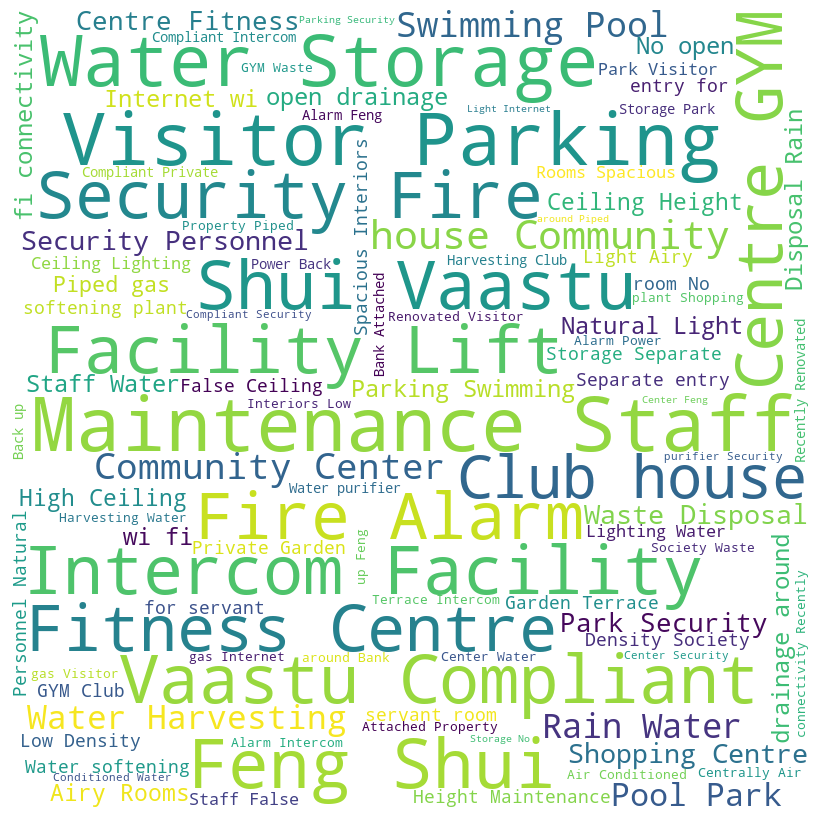

In [24]:
from wordcloud import WordCloud


plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=set(['s']),  # customize stopwords here
    min_font_size=10
).generate(feature_text)

plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')  # ✅ corrected spelling
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [26]:
# exporting feature test 

import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb')) # write binary

# Scatter plot vs Area

In [ ]:
fig = px.scatter(df, x="built_up_area", y ="price", color="bedRoom")

# Show the plot 
fig.show()

# Pie chart bhk filter by sector 

In [29]:
fig = px.pie(df, names='bedRoom', title='Total Amount By Day')

fig.show()

# Side by side boxplot bedroom price

In [30]:
temp_df = df[df['bedRoom']<=4]
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()

<Axes: xlabel='price', ylabel='Density'>

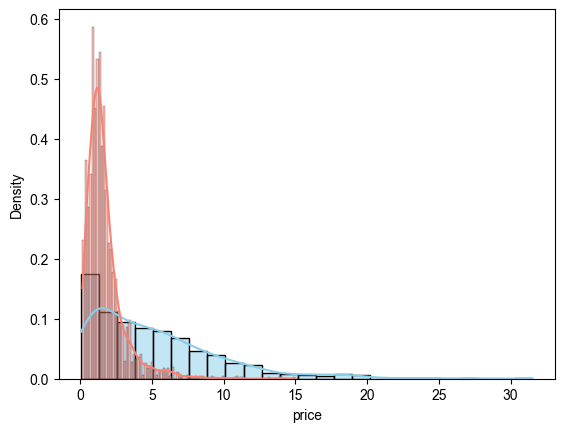

In [33]:

sns.histplot(df[df['property_type'] == 'house']['price'], kde=True, color='skyblue', label='House', stat='density')
sns.histplot(df[df['property_type'] == 'flat']['price'], kde=True, color='salmon', label='Flat', stat='density')
